In [4]:
import matplotlib.pyplot as plt
import uncertainties as unc
from uncertainties.umath import atan
from uncertainties import unumpy as unp
import numpy as np 
from scipy.optimize import curve_fit
import pandas as pd
import scipy.signal as ssi

# Task 2

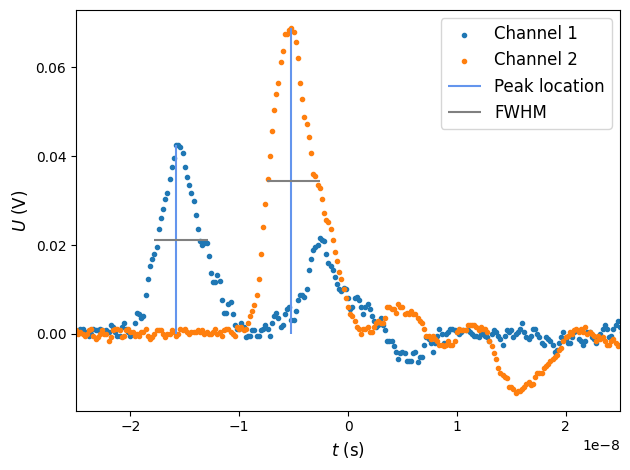

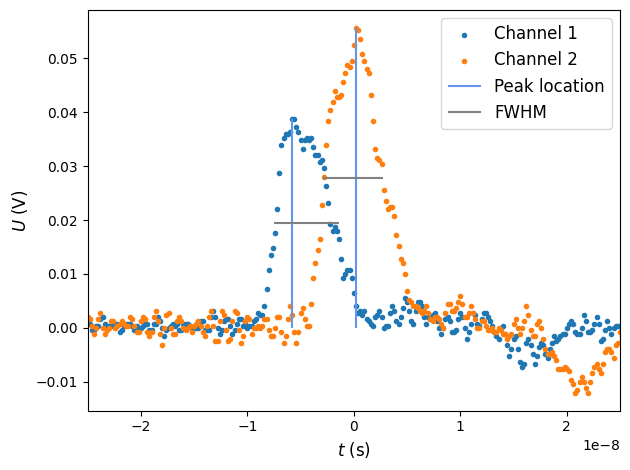

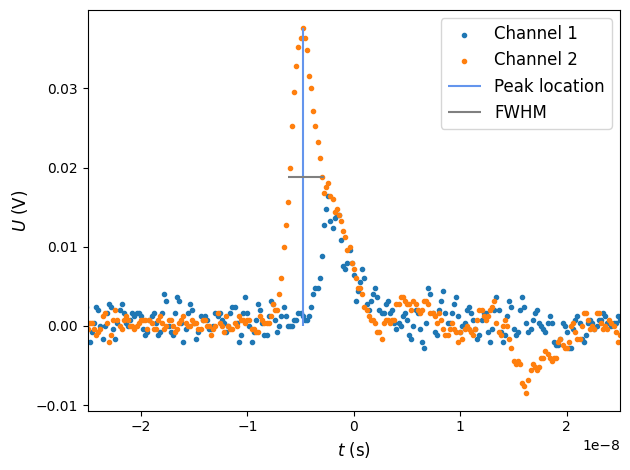

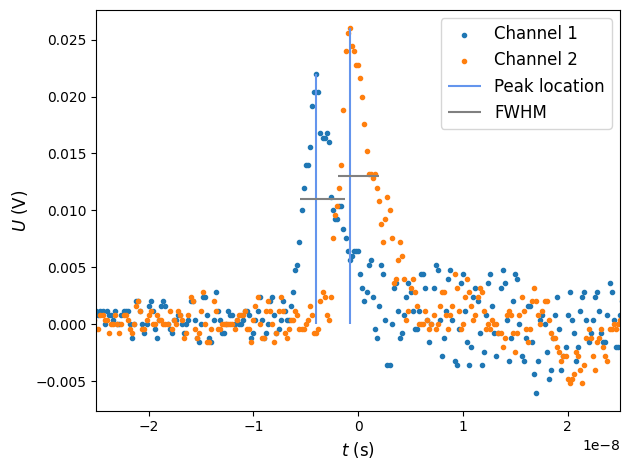

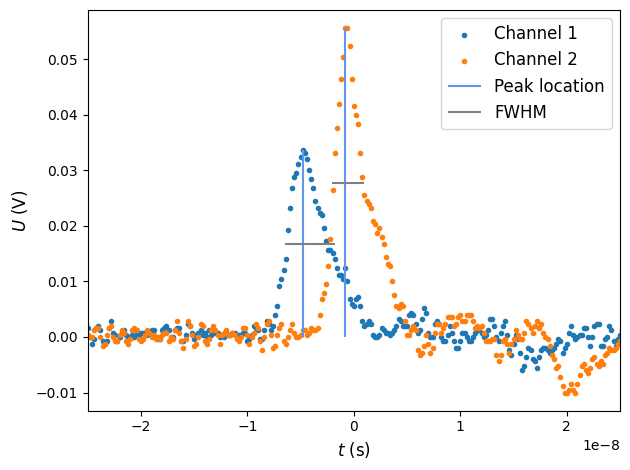

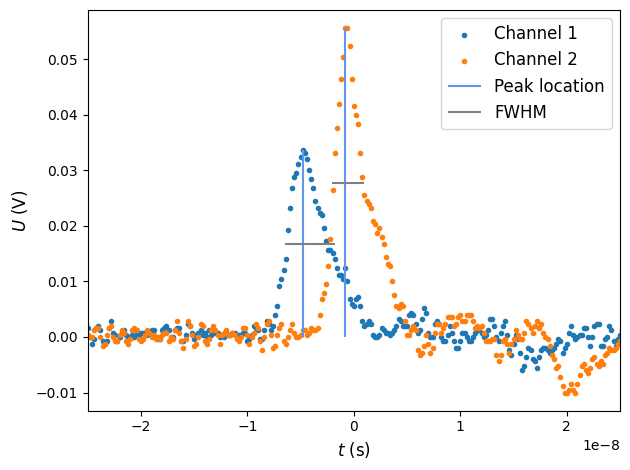

Error processing file tek0021.csv: No peaks found in Channel 1


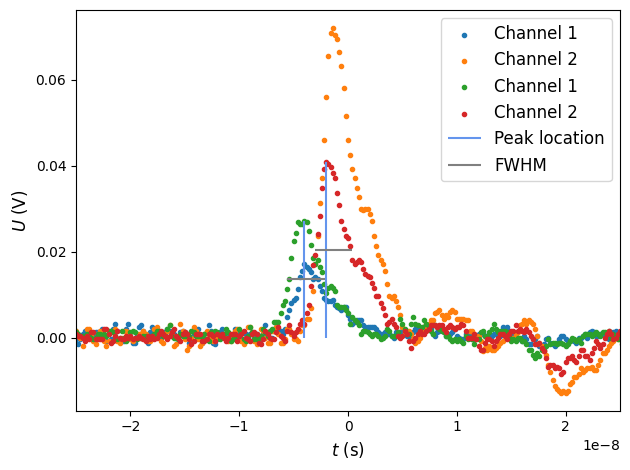

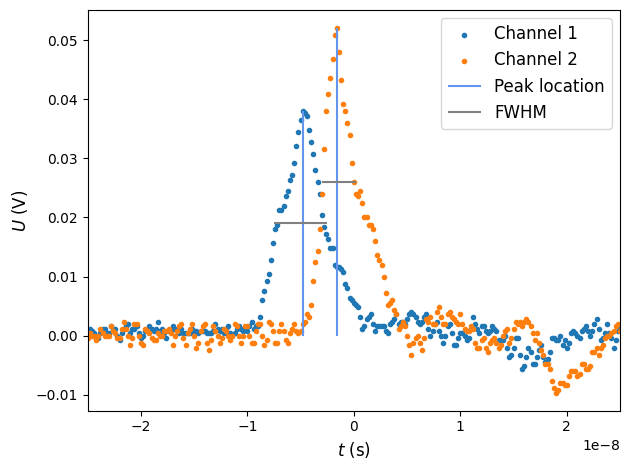

Results: [1.0599999999999999e-08+/-3.4884974577134006e-09
 6e-09+/-4.135717575153349e-09 7.4404e-06+/-2.527833848686548e-09
 3.2e-09+/-2.8984623826560432e-09 4e-09+/-2.7604720408708132e-09
 4e-09+/-2.7604720408708132e-09 2e-09+/-2.44117514961745e-09
 3.1999999999999997e-09+/-2.9264723758012924e-09]
[1.0599999999999999e-08+/-3.4884974577134006e-09
 6e-09+/-4.135717575153349e-09 3.2e-09+/-2.8984623826560432e-09
 4e-09+/-2.7604720408708132e-09 4e-09+/-2.7604720408708132e-09
 2e-09+/-2.44117514961745e-09
 3.1999999999999997e-09+/-2.9264723758012924e-09] cleared
(4.7+/-1.2)e-09 durschnittszeit
7 laenge
(3.5+/-0.9)e+08 muonspeed
225407863.15789473


In [5]:
def berechnung_time_difference(file):
    file_path = file
    data = pd.read_csv(
        file_path, 
        skiprows=21,  
        names=["Time", "Channel1", "Channel2"] 
    )

    times = data['Time'].values
    channel1 = data['Channel1'].values
    channel2 = data['Channel2'].values
    
    plt.scatter(times, channel1, marker=".", label="Channel 1")
    plt.scatter(times, channel2, marker=".", label="Channel 2")
    plt.xlim(-0.025e-6, 0.025e-6)
    
    # Peaks in Channel 1
    peaks1, properties1 = ssi.find_peaks(channel1, height=0.02, distance=100)
    if len(peaks1) == 0:
        raise ValueError(f"No peaks found in Channel 1")
    
    peak_heights1 = properties1["peak_heights"]
    index_maxpeak1 = np.argmax(peak_heights1)
    maxpeak1 = peaks1[index_maxpeak1]
    
    # Peak widths for Channel 1
    peak_widths1 = ssi.peak_widths(channel1, [maxpeak1], rel_height=0.5)
    left_time1 = np.interp(peak_widths1[2][0], np.arange(len(times)), times)
    right_time1 = np.interp(peak_widths1[3][0], np.arange(len(times)), times)
    time_width1 = right_time1 - left_time1
    
    plt.vlines(times[maxpeak1], ymin=0, ymax=channel1[maxpeak1], color='cornflowerblue', label="Peak location")
    plt.hlines(channel1[maxpeak1] / 2, xmin=left_time1, xmax=right_time1, color='grey', label='FWHM')
    
    # Peaks in Channel 2
    peaks2, properties2 = ssi.find_peaks(channel2, height=0.02, distance=100)
    if len(peaks2) == 0:
        raise ValueError(f"No peaks found in Channel 2")
    
    peak_heights2 = properties2["peak_heights"]
    index_maxpeak2 = np.argmax(peak_heights2)
    maxpeak2 = peaks2[index_maxpeak2]
    
    # Peak widths for Channel 2
    peak_widths2 = ssi.peak_widths(channel2, [maxpeak2], rel_height=0.5)
    left_time2 = np.interp(peak_widths2[2][0], np.arange(len(times)), times)
    right_time2 = np.interp(peak_widths2[3][0], np.arange(len(times)), times)
    time_width2 = right_time2 - left_time2
    
    plt.vlines(times[maxpeak2], ymin=0, ymax=channel2[maxpeak2], color='cornflowerblue')
    plt.hlines(channel2[maxpeak2] / 2, xmin=left_time2, xmax=right_time2, color='grey')
    plt.xlabel("$t$ (s)", fontsize=12)
    plt.ylabel("$U$ (V)", fontsize=12)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    peakpos1 = unc.ufloat(times[maxpeak1], time_width1/2)
    peakpos2 = unc.ufloat(times[maxpeak2], time_width2/2)
    time_difference = peakpos2 - peakpos1
    
    return time_difference


file_list = ["tek0014.csv", "tek0015.csv", "tek0016.csv", "tek0017.csv", "tek0019.csv", "tek0020.csv", "tek0021.csv", "tek0023.csv", "tek0024.csv"]
# files, where at least one peak is not visible, are removed 
nominal_values = [] 
std_devs = []

for file in file_list:
    try:
        result = berechnung_time_difference(file) 
        nominal_values.append(result.nominal_value)  
        std_devs.append(result.std_dev)  
    except ValueError as e:
        print(f"Error processing file {file}: {e}")

results_uarray = unp.uarray(nominal_values, std_devs)
print("Results:", results_uarray)


results_uarray_cleared=np.delete(results_uarray, 2)

print(results_uarray_cleared, "cleared")

meantime=sum(results_uarray_cleared)/len(results_uarray_cleared)
print(meantime, "durschnittszeit")
height=unc.ufloat(1.664, 0.02)
print(len(results_uarray_cleared), "laenge")
speed=height/meantime

print(speed, "muonspeed")

from scipy.constants import c
print(c/1.33)

# Task 3

0.42798125349503296
[ 4.19021544  2.78053766 -0.66618838]
[0.4018506  0.28907769 0.19808156]
[0.41318355502757287+/-0.7304037931082322
 16.97682566702478+/-0.8406104310197103
 33.967277456246585+/-0.7788839838596918
 42.987011206932486+/-0.7070303852804117]


<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:53: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:53: SyntaxWarning: invalid escape sequence '\c'
C:\Users\maxko\AppData\Local\Temp\ipykernel_21212\2169060798.py:50: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Angle ($^\circ$)", fontsize=12)
C:\Users\maxko\AppData\Local\Temp\ipykernel_21212\2169060798.py:53: SyntaxWarning: invalid escape sequence '\c'
  "$f(x)=a \cdot cos(b \cdot x \cdot \pi /180^{\circ}+c)$\n a= 4.2(4) min$^{-1}$ \n b=2.8(3) \n c=-0.7(2)\n $\chi_{red}^2=0.428$",\


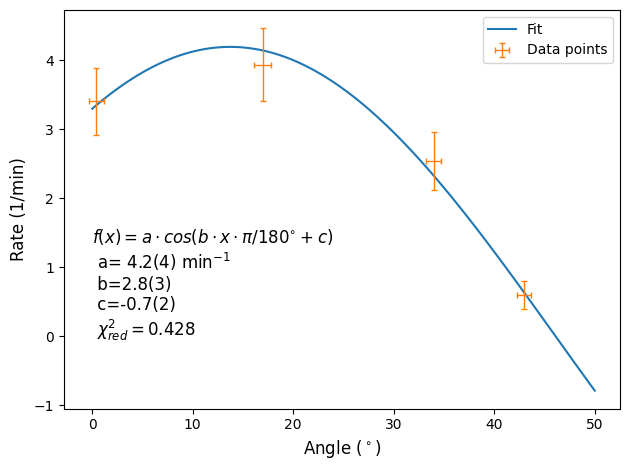

In [6]:
r=unc.ufloat(15, 0)
h=unc.ufloat(166.4, 2)
d1=unc.ufloat(13,1.5)
d2=unc.ufloat(11.8,1.5)
d3=unc.ufloat(22,1.5)
d4=unc.ufloat(31.3,1.5)
d5=unc.ufloat(13,1.5)

alpha1=atan((d1+r-d2-r)/(h))
#print(alpha1)

alpha2=atan(-(d1+r-(d2+2*r+d3+r))/(h))

alpha3=atan(-(d1+r-(d2+2*r+d3+2*r+d4+r))/(h))
alpha4=atan(-(d1+r-(d2+2*r+d3+2*r+d4+2*r+d5+r))/(h))

angles=unp.uarray([alpha1.nominal_value, alpha2.nominal_value, alpha3.nominal_value, alpha4.nominal_value], \
                  [alpha1.std_dev, alpha2.std_dev, alpha3.std_dev, alpha4.std_dev])*180/np.pi

#print(angles)
timeinterval=unc.ufloat(15, 0.5)
counts=unp.uarray([51,59,38,9], [np.sqrt(51), np.sqrt(59), np.sqrt(38), np.sqrt(9)])
#print(counts)
rate=counts/timeinterval
#print(rate)


    

def cosfkt(x, a,b,c):
    return a*np.cos(b*x/180*np.pi+c)

popt, pcov = curve_fit(cosfkt, unp.nominal_values(angles),  unp.nominal_values(rate), \
                       sigma= unp.std_devs(rate), absolute_sigma=True)

residuals = unp.nominal_values(rate) - cosfkt(unp.nominal_values(angles), *popt)
chi_square = np.sum((residuals / unp.std_devs(rate)) ** 2)
dof = len(unp.nominal_values(rate)) - len(popt)
reduced_chi_square = chi_square / dof

print(reduced_chi_square)

print(popt)
print(np.sqrt(np.diag(pcov)))
xrange=np.linspace(0,50,100)
plt.plot(xrange, cosfkt(xrange, *popt), label='Fit')
plt.errorbar(unp.nominal_values(angles), unp.nominal_values(rate), xerr=unp.std_devs(angles), \
             yerr=unp.std_devs(rate), linestyle='none', fmt='', capsize=2, capthick=1, elinewidth=1, label='Data points')
plt.legend()
plt.xlabel("Angle ($^\circ$)", fontsize=12)
plt.ylabel("Rate (1/min)", fontsize=12)
plt.text(0,0, \
         "$f(x)=a \cdot cos(b \cdot x \cdot \pi /180^{\circ}+c)$\n a= 4.2(4) min$^{-1}$ \n b=2.8(3) \n c=-0.7(2)\n $\chi_{red}^2=0.428$",\
              fontsize=12)

plt.tight_layout()
plt.savefig("winkelabhaengigkeit.pdf")

print(angles)